# Customer Churn Prediction Model

## Objective

The objective of this notebook is to build a machine learning model capable of predicting customer churn.

By identifying customers who are likely to leave, businesses can implement proactive retention strategies and reduce customer attrition.

A Logistic Regression classifier is used as a baseline predictive model.

In [1]:
%pip install seaborn

In [2]:
# ============================
# Import Libraries
# ============================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# ============================
# Load Dataset
# ============================

df = pd.read_csv(
    "/drive/customer-churn-analytics-project/data/customer_churn_segmented.csv"
)

df.head()

,City,Zip Code,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,...,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason,Cluster,Risk Cluster
0,Los Angeles,90003,Male,No,No,No,2,Yes,No,DSL,...,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer,1,High Risk
1,Los Angeles,90005,Female,No,No,Yes,2,Yes,No,Fiber optic,...,Electronic check,70.70,151.65,Yes,1,67,2701,Moved,1,High Risk
2,Los Angeles,90006,Female,No,No,Yes,8,Yes,Yes,Fiber optic,...,Electronic check,99.65,820.50,Yes,1,86,5372,Moved,1,High Risk
3,Los Angeles,90010,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,...,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved,1,High Risk
4,Los Angeles,90015,Male,No,No,Yes,49,Yes,Yes,Fiber optic,...,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices,2,Medium Risk


## Feature Selection

Only numerical features with predictive value are selected for the baseline model.

In [4]:
features = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "Churn Score",
    "CLTV"
]

X = df[features]

y = df["Churn Value"]

## Train-Test Split

The dataset is divided into training and testing subsets using an 80/20 split.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## Feature Scaling

The numerical variables are standardized before model training.

In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

## Model Training

A Logistic Regression classifier is trained using the scaled training data.

In [7]:
model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

model.fit(
    X_train_scaled,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [8]:
y_pred = model.predict(
    X_test_scaled
)

In [9]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9097


In [10]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.93      0.94      0.94      1033
           1       0.84      0.82      0.83       374

    accuracy                           0.91      1407
   macro avg       0.89      0.88      0.88      1407
weighted avg       0.91      0.91      0.91      1407



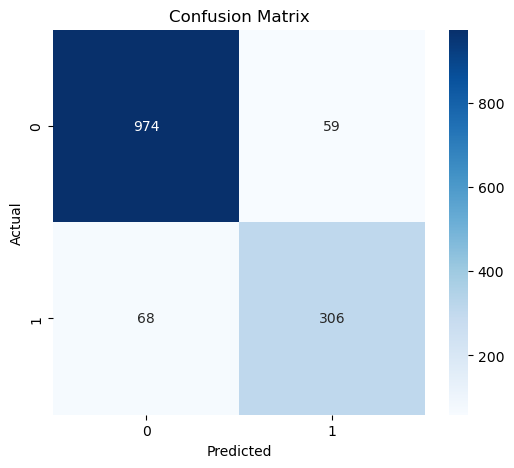

In [11]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# Model Performance Summary

The Logistic Regression model achieved an overall accuracy of **90.97%** on the test dataset.

Performance metrics indicate strong predictive capability:

- Accuracy: 90.97%
- Precision (Churn): 84%
- Recall (Churn): 82%
- F1-Score (Churn): 83%

The model successfully distinguishes between retained and churned customers and provides a reliable baseline for customer retention analytics.

## Key Insight

The predictive model demonstrates that customer churn can be estimated with high reliability using behavioral and financial variables.

Features such as tenure, monthly charges, customer lifetime value (CLTV), and churn score contribute significantly to prediction performance, enabling businesses to proactively identify customers at risk of leaving.